In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv("bank_transactions_data_2_augmented_clean_2.csv")

In [3]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  str    
 1   AccountID            50000 non-null  str    
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  str    
 4   TransactionType      50000 non-null  str    
 5   Location             50000 non-null  str    
 6   DeviceID             50000 non-null  str    
 7   IP Address           50000 non-null  str    
 8   MerchantID           50000 non-null  str    
 9   Channel              50000 non-null  str    
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  str    
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), str(10)
memory usage: 

In [5]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [6]:
df.duplicated().sum().sum()

np.int64(0)

In [7]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='str')

In [8]:
count_col = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

for i in count_col:
    print("=" *20)
    print(df[i].value_counts())

TransactionType
Debit     38747
Credit    11253
Name: count, dtype: int64
Location
Fort Worth          1396
Charlotte           1347
Oklahoma City       1345
Philadelphia        1343
Memphis             1330
Tucson              1322
Los Angeles         1318
Omaha               1298
Miami               1278
Denver              1267
Atlanta             1245
Detroit             1230
Mesa                1228
Houston             1217
Jacksonville        1216
Kansas City         1211
Seattle             1208
Boston              1203
San Antonio         1195
Chicago             1195
Raleigh             1187
Fresno              1177
San Jose            1159
Phoenix             1155
New York            1150
Austin              1146
Colorado Springs    1141
San Diego           1139
Nashville           1124
Las Vegas           1124
San Francisco       1105
Indianapolis        1104
Milwaukee           1100
Virginia Beach      1075
Sacramento          1055
Columbus            1048
Louisville       

In [9]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="mixed")

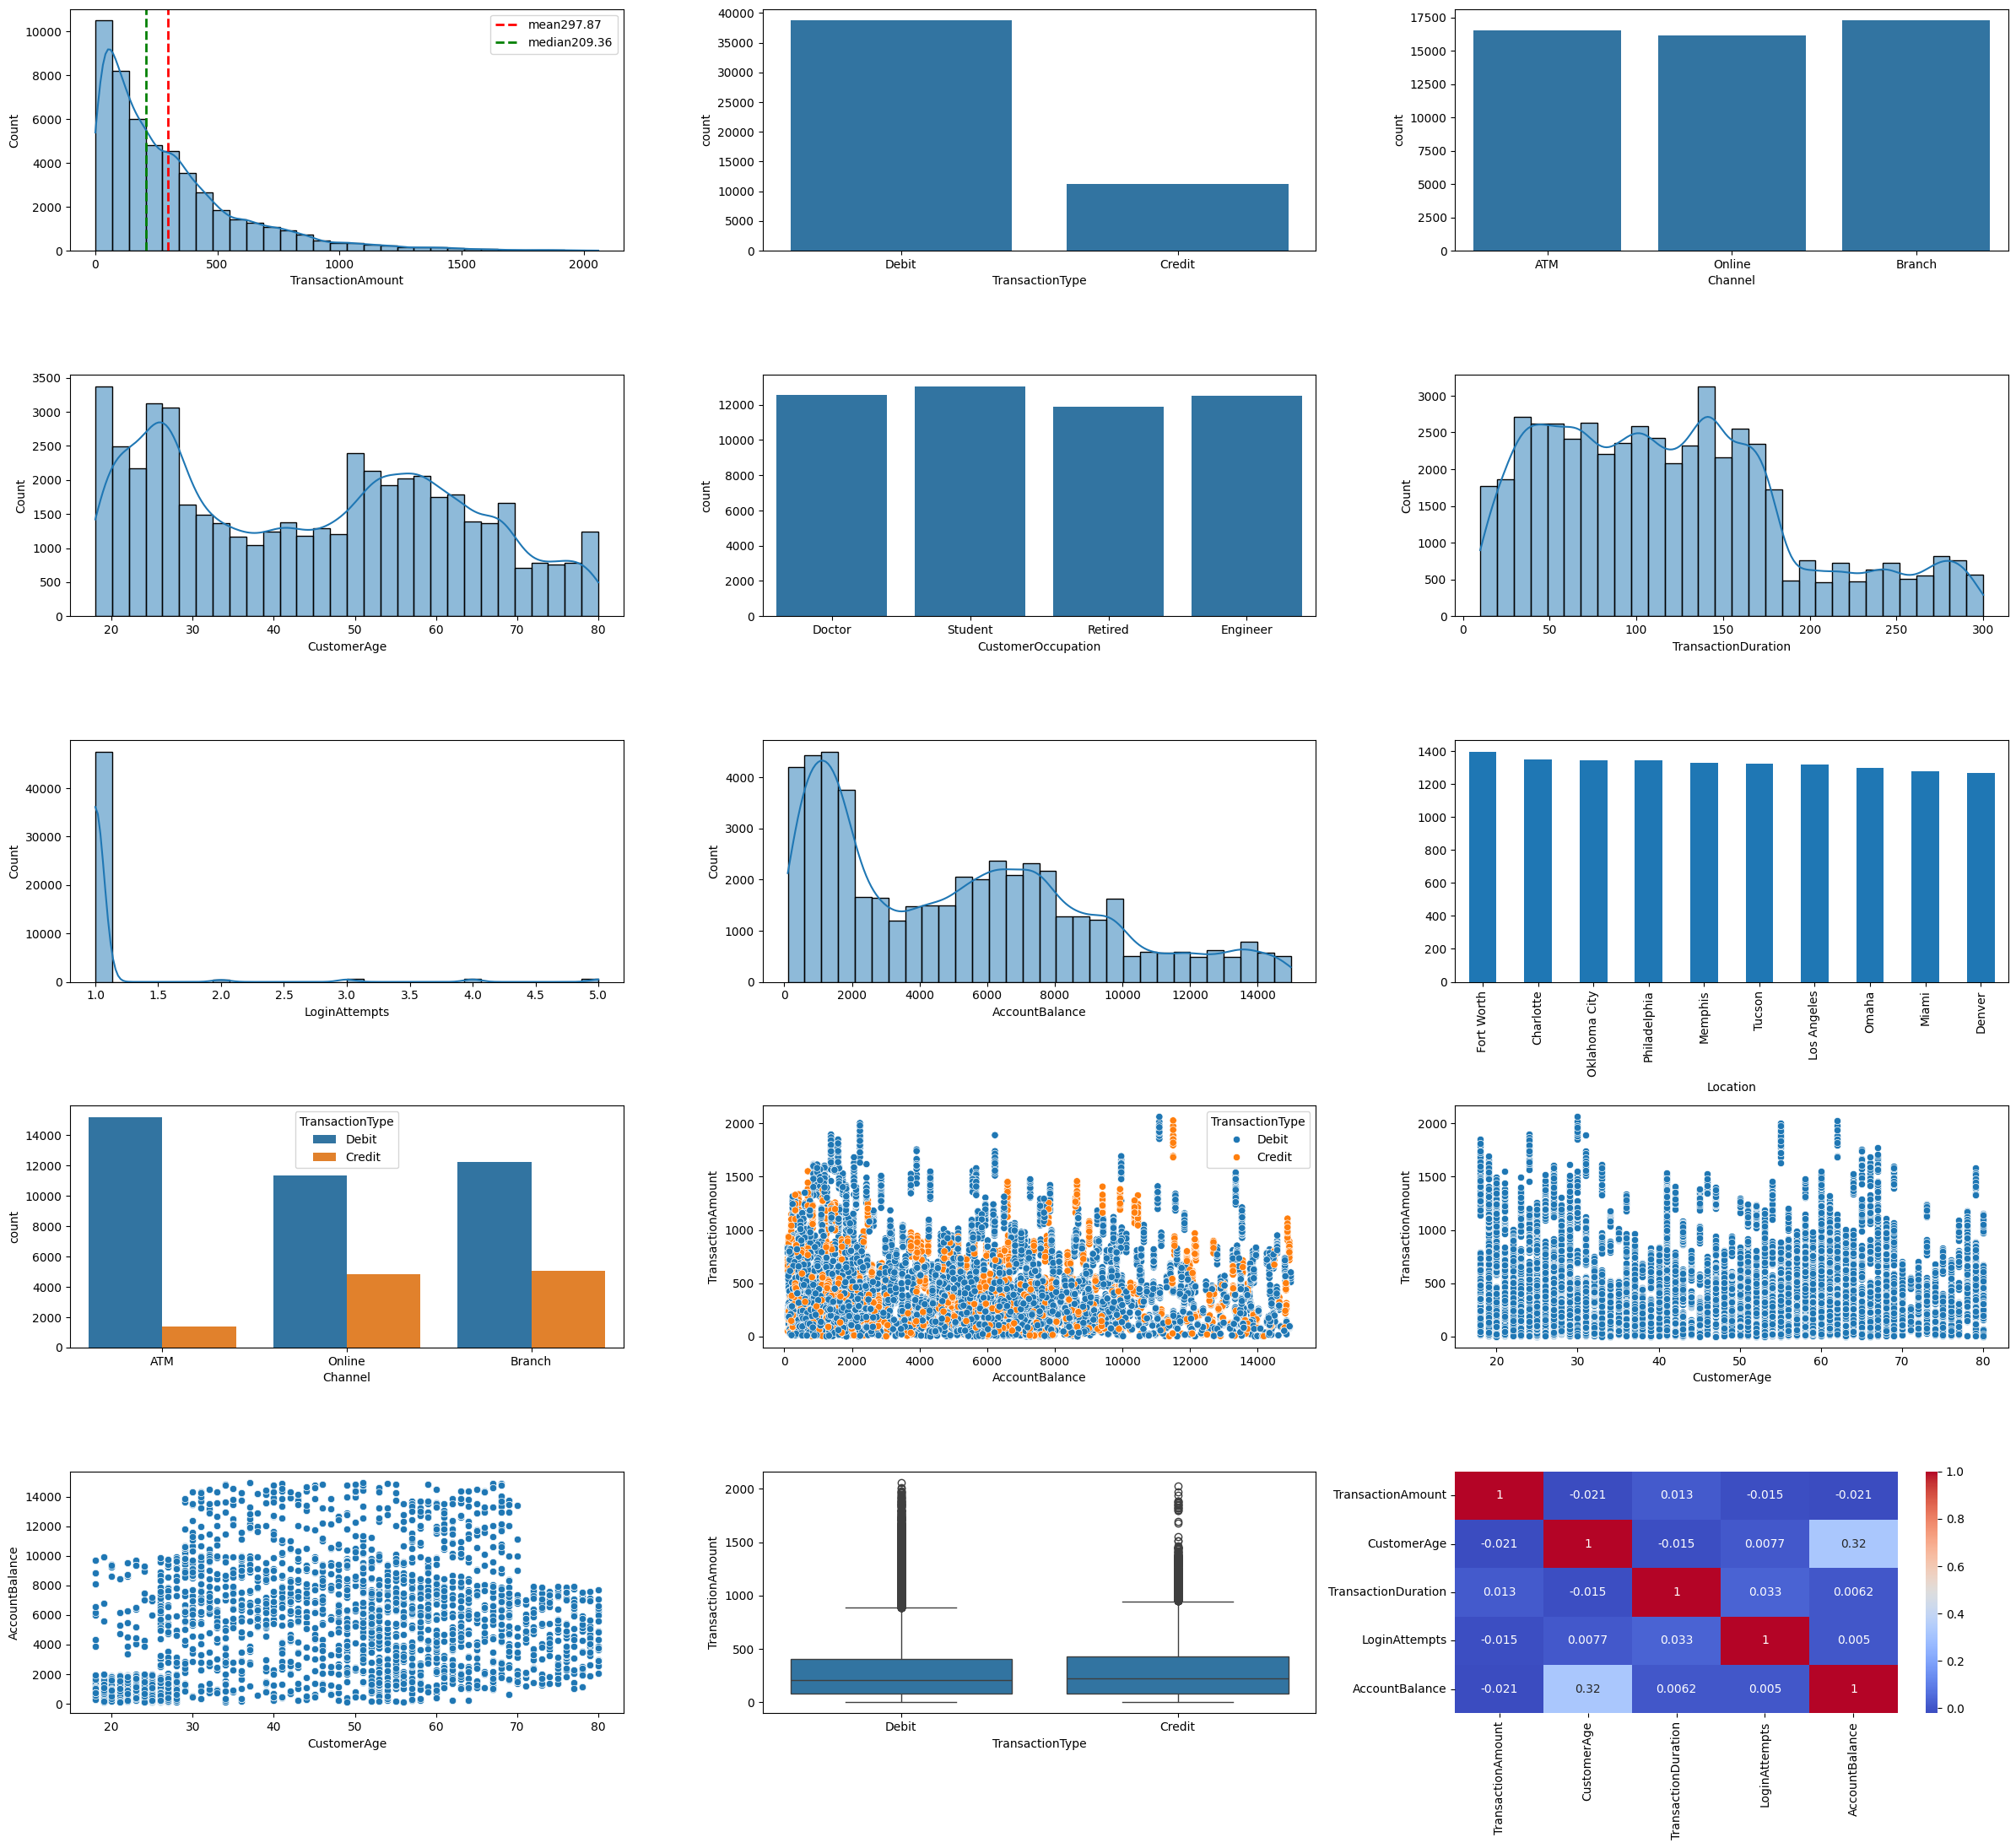

In [10]:
fig, axes = plt.subplots(5, 3, figsize=(24, 22))

sns.histplot(df["TransactionAmount"], bins=30, ax=axes[0, 0], kde=True)
axes[0, 0].axvline(x=df["TransactionAmount"].mean(), color='red', linestyle='--', linewidth=2, label=f'mean{df["TransactionAmount"].mean():.2f}')
axes[0, 0].axvline(x=df["TransactionAmount"].median(), color='green', linestyle='--', linewidth=2, label=f'median{df["TransactionAmount"].median():.2f}')
axes[0, 0].legend()

sns.countplot(data=df, x="TransactionType", ax=axes[0, 1])

sns.countplot(data=df, x="Channel", ax=axes[0, 2])

sns.histplot(df["CustomerAge"], bins=30, ax=axes[1, 0], kde=True)

sns.countplot(data=df, x="CustomerOccupation", ax=axes[1, 1])

sns.histplot(df["TransactionDuration"], bins=30, ax=axes[1, 2], kde=True)

sns.histplot(df["LoginAttempts"], bins=30, ax=axes[2, 0], kde=True)

sns.histplot(df["AccountBalance"], bins=30, ax=axes[2, 1], kde=True)

df['Location'].value_counts().head(10).plot(kind='bar', ax=axes[2, 2])

sns.countplot(data=df, x="Channel", hue="TransactionType", ax=axes[3,0])

sns.scatterplot(data=df, x="AccountBalance", y="TransactionAmount", hue="TransactionType", ax=axes[3,1])

sns.scatterplot(data=df, x="CustomerAge", y="TransactionAmount", ax=axes[3, 2])

sns.scatterplot(data=df, x="CustomerAge", y="AccountBalance", ax=axes[4,0])

sns.boxplot(x='TransactionType', y='TransactionAmount', data=df, ax=axes[4, 1])

numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=axes[4,2])

plt.tight_layout()
plt.show()

# Studying Transaction Duration

In [11]:
#Converting to Minutes and focus on debit

df["TransactionMinute"] = df["TransactionDuration"] / 60
df2=df.copy()
df2_debit = df[df["TransactionType"] == "Debit"]

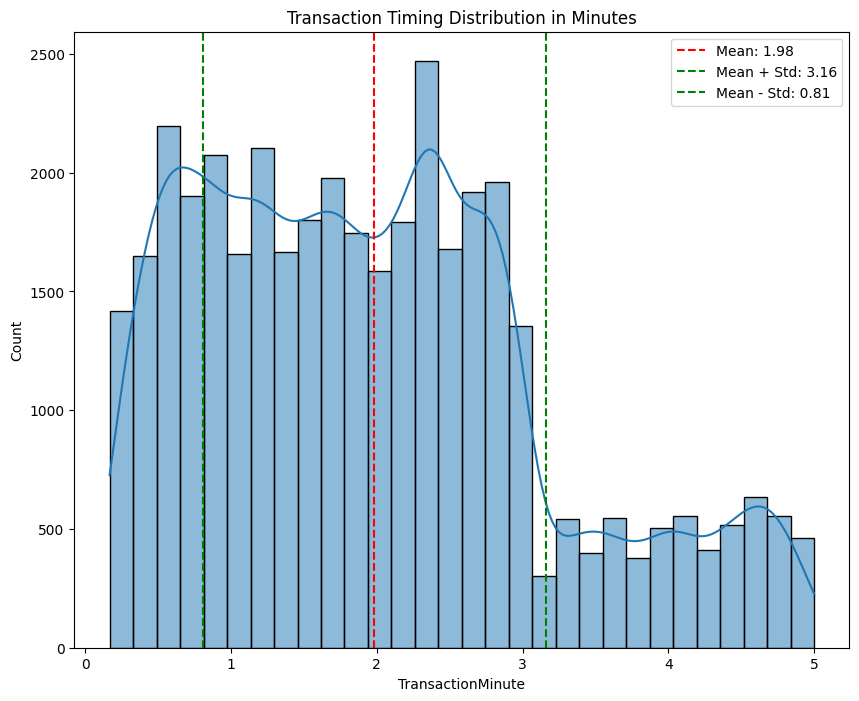

In [12]:
#Checking Transaction/Minutes spread
mean = df2_debit["TransactionMinute"].mean()
std = df2_debit["TransactionMinute"].std()

plt.figure(figsize=(10, 8))

sns.histplot(df2_debit["TransactionMinute"], bins=30, kde=True)

plt.axvline(mean, linestyle="--", color="red", label=f"Mean: {mean:.2f}")
plt.axvline(mean + std, linestyle="--", color="green", label=f"Mean + Std: {mean+std:.2f}")
plt.axvline(mean - std, linestyle="--", color="green", label=f"Mean - Std: {mean-std:.2f}")

plt.title("Transaction Timing Distribution in Minutes")
plt.legend()
plt.show()

In [13]:
#Splitting transactions into (More than the normal transaction spread (Suspicious Transactions) and within the normal transaction spread)
df_fr = df2_debit[df2_debit["TransactionMinute"] > 3.16]
df_nofr = df2_debit[df2_debit["TransactionMinute"] < 3.16]

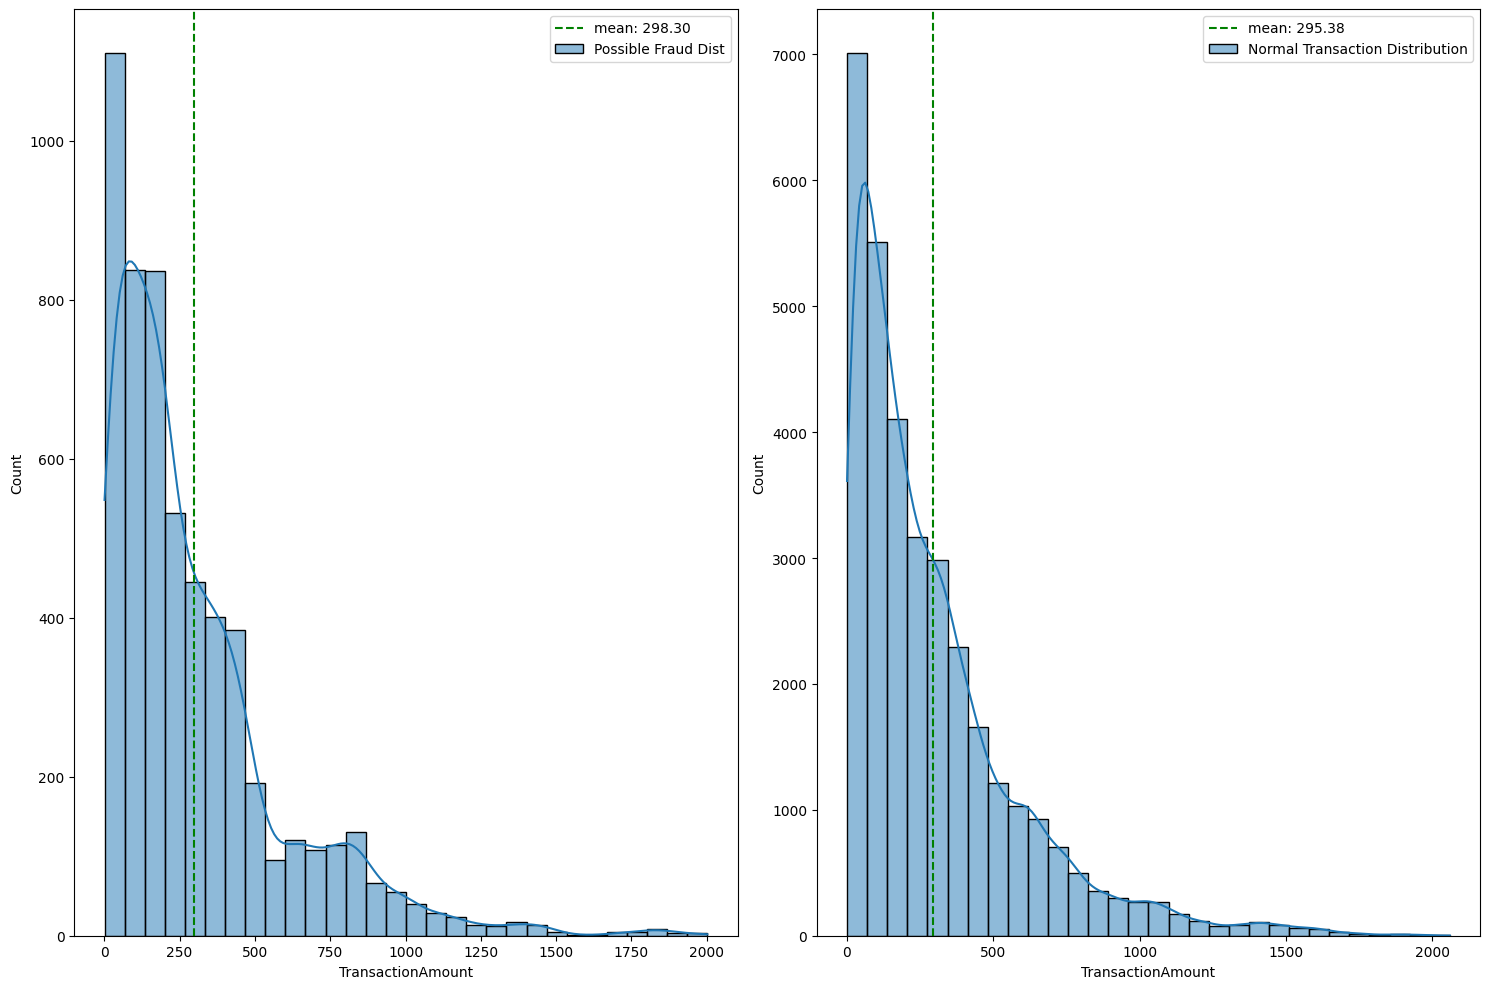

In [14]:
#Using mean to find difference between the 2 splitted kind of transaction
fig, axes= plt.subplots(1,2, figsize=(15, 10))

sns.histplot(df_fr["TransactionAmount"], bins=30, label="Possible Fraud Dist", ax=axes[0], kde=True)
axes[0].axvline(df_fr["TransactionAmount"].mean(), linestyle="--", color="green", label=f"mean: {df_fr['TransactionAmount'].mean():.2f}")
sns.histplot(df_nofr["TransactionAmount"], bins=30, label="Normal Transaction Distribution", ax=axes[1], kde=True)
axes[1].axvline(df_nofr["TransactionAmount"].mean(), linestyle="--", color="green", label=f"mean: {df_nofr['TransactionAmount'].mean():.2f}")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [15]:
#Checking if difference is statistically significant

tstats, p_value = ttest_ind(df_fr["TransactionAmount"], df_nofr["TransactionAmount"], equal_var=False)
print(tstats)
print(p_value)

0.6874477642249001
0.4918215433759301


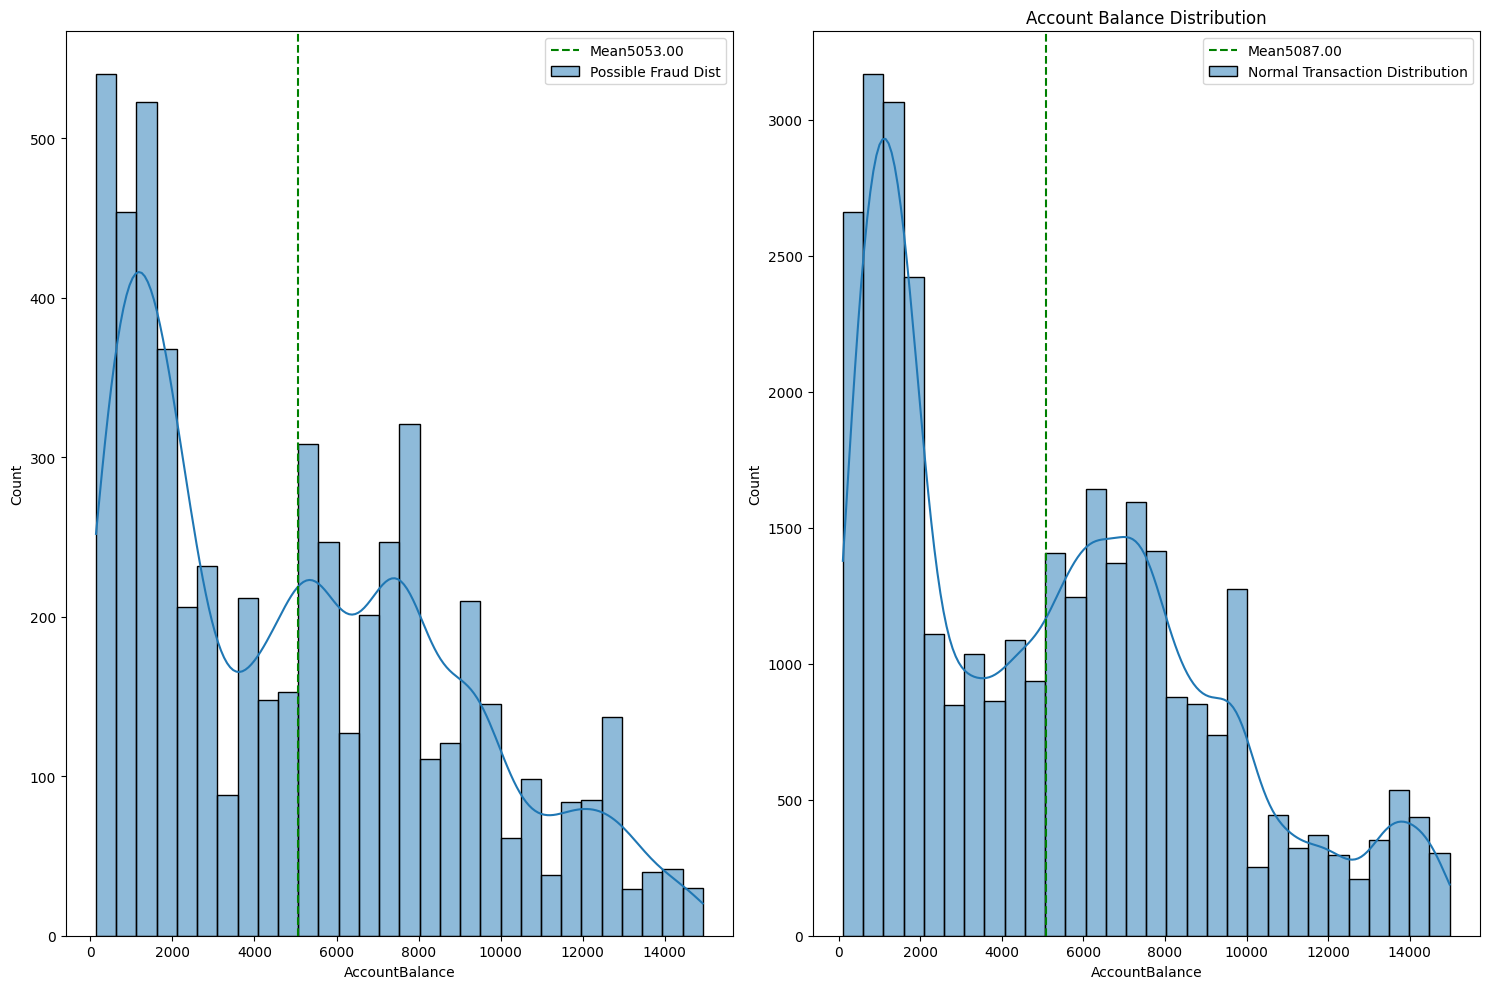

In [16]:
fig, axes= plt.subplots(1,2, figsize=(15, 10))
mean_fr = df_fr["AccountBalance"].mean()
mean_nofr = df_nofr["AccountBalance"].mean()

sns.histplot(df_fr["AccountBalance"], bins=30, label="Possible Fraud Dist", ax=axes[0], kde=True)
axes[0].axvline(mean_fr, linestyle="--", color="green", label=f"Mean{mean_fr:.2f}")
sns.histplot(df_nofr["AccountBalance"], bins=30, label="Normal Transaction Distribution", ax=axes[1], kde=True)
axes[1].axvline(mean_nofr, linestyle="--", color="green", label=f"Mean{mean_nofr:.2f}")
axes[0].legend()
axes[1].legend()
plt.title("Account Balance Distribution")
plt.tight_layout()
plt.show()

# Note

After checking the correlation of minutes used to make a transaction to possible fraud, patterns of it to non suspiscious transactions are almost similar and not statistically significant. so depending on minutes per transaction to tell suspiscious transactions is unreliable.

Checking login frequency in relation to transaction per minute grouped by ip address will give more insight

In [17]:
ip_group=df2_debit.groupby("IP Address")[["TransactionAmount", "LoginAttempts", "TransactionMinute"]].mean().reset_index()
ip_group = ip_group.sort_values(ascending=False, by="LoginAttempts")

In [18]:
ip_group.head(10)

,IP Address,TransactionAmount,LoginAttempts,TransactionMinute
542,85.191.79.161,141.825882,4.000000,0.450000
110,140.94.123.72,262.688095,3.380952,2.132937
393,34.92.221.183,61.601212,3.303030,2.959091
48,114.223.129.47,240.965581,3.139535,3.115504
456,55.139.104.163,97.158444,3.044444,1.496296
103,138.210.196.19,426.746286,2.971429,3.638571
87,133.223.159.151,192.484694,2.530612,2.753401
137,148.234.210.167,209.895000,2.500000,1.391667
307,203.245.215.62,207.828966,2.379310,2.144828
501,7.146.35.122,339.067333,2.186667,2.030667


User IP 85.191.79.161 transacts a typical amount of 141.83 in an average of 4 login attempts spending less than 1 minute in this transaction. Automated?????

<Axes: >

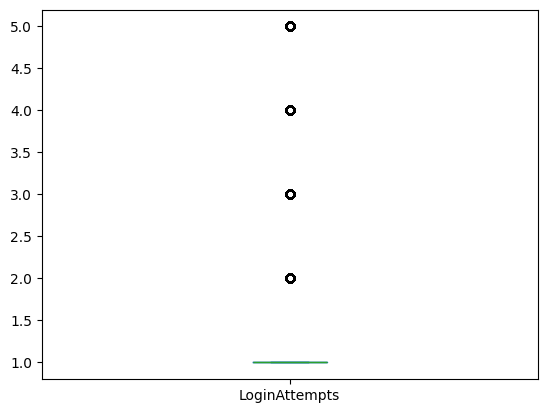

In [19]:
df2_debit["LoginAttempts"].plot.box()

In [20]:
sus = df2_debit[(df2_debit["LoginAttempts"] >= 3) & (df2_debit["TransactionMinute"] <= 1)]
non_sus = df2_debit[(df2_debit["LoginAttempts"] < 3) & (df2_debit["TransactionMinute"] > 1)]

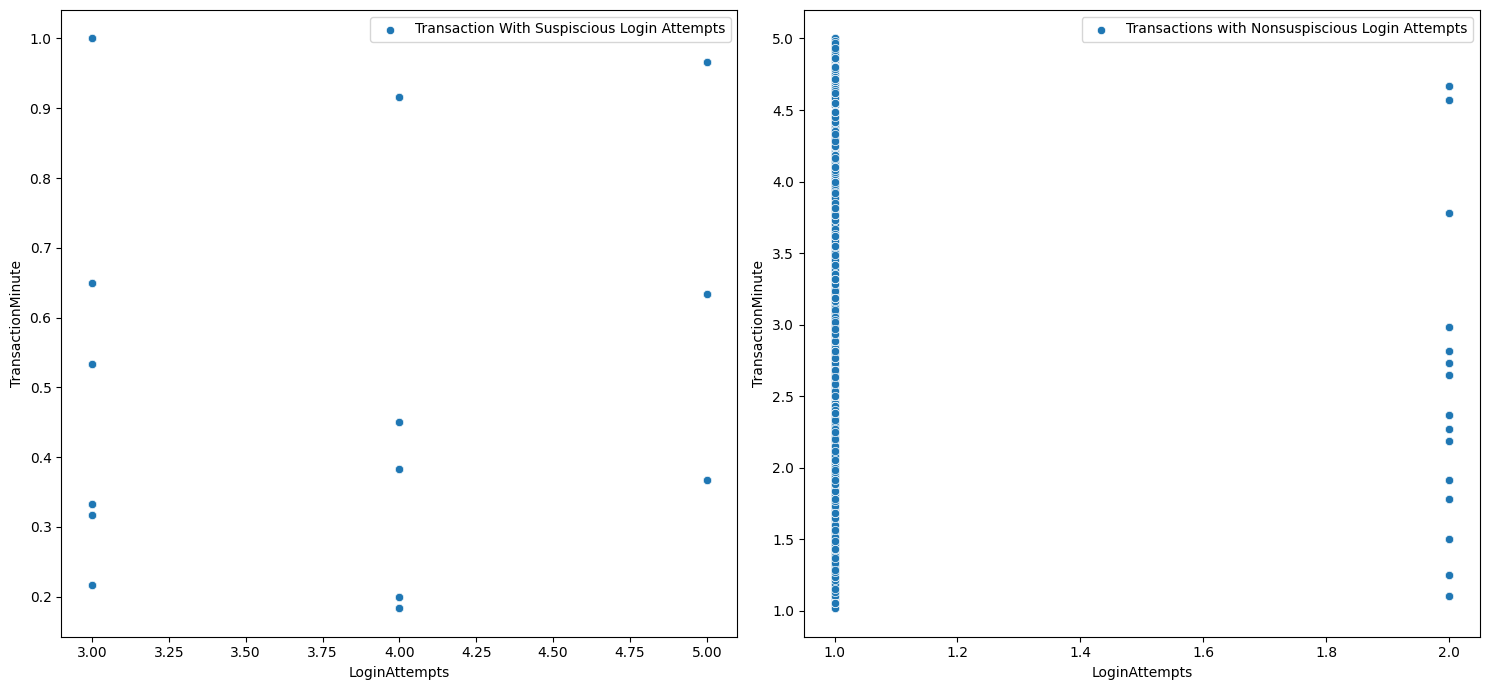

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.scatterplot(data=sus, x="LoginAttempts", y="TransactionMinute", label="Transaction With Suspiscious Login Attempts", ax=axes[0])
axes[0].legend()
sns.scatterplot(data=non_sus, x="LoginAttempts", y="TransactionMinute", label="Transactions with Nonsuspiscious Login Attempts", ax=axes[1])
axes[1].legend()
plt.tight_layout()
plt.show()

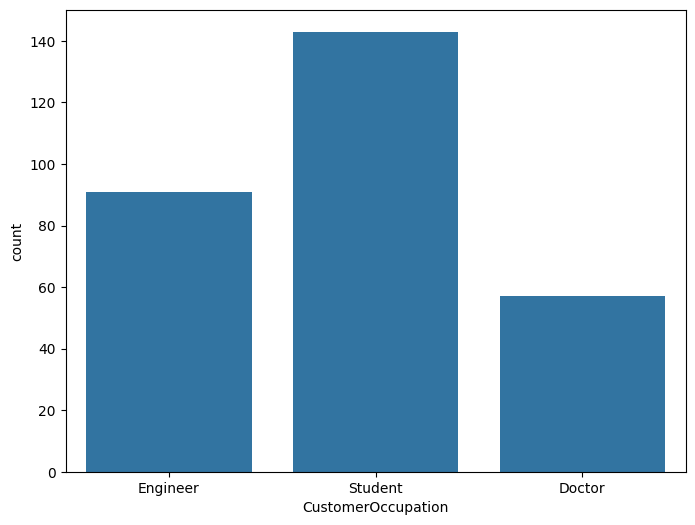

In [22]:
plt.figure(figsize=(8, 6))
sns.countplot(data=sus, x="CustomerOccupation")
plt.show()

In [23]:
sus.TransactionAmount.mean(), non_sus.TransactionAmount.mean()

(np.float64(124.77907216494845), np.float64(301.75056316482267))

In [24]:
tstats, p_value = ttest_ind(sus["TransactionAmount"], non_sus["TransactionAmount"], equal_var=False)
print("tstats:", tstats)
print("pvalue:", p_value)

tstats: -28.616152861200806
pvalue: 4.500917984217327e-93


Above shows p-value of roughly 0.000004, which is very much significant, but suspiscious transactions amount is not upto non suspiscious transaction amount on average

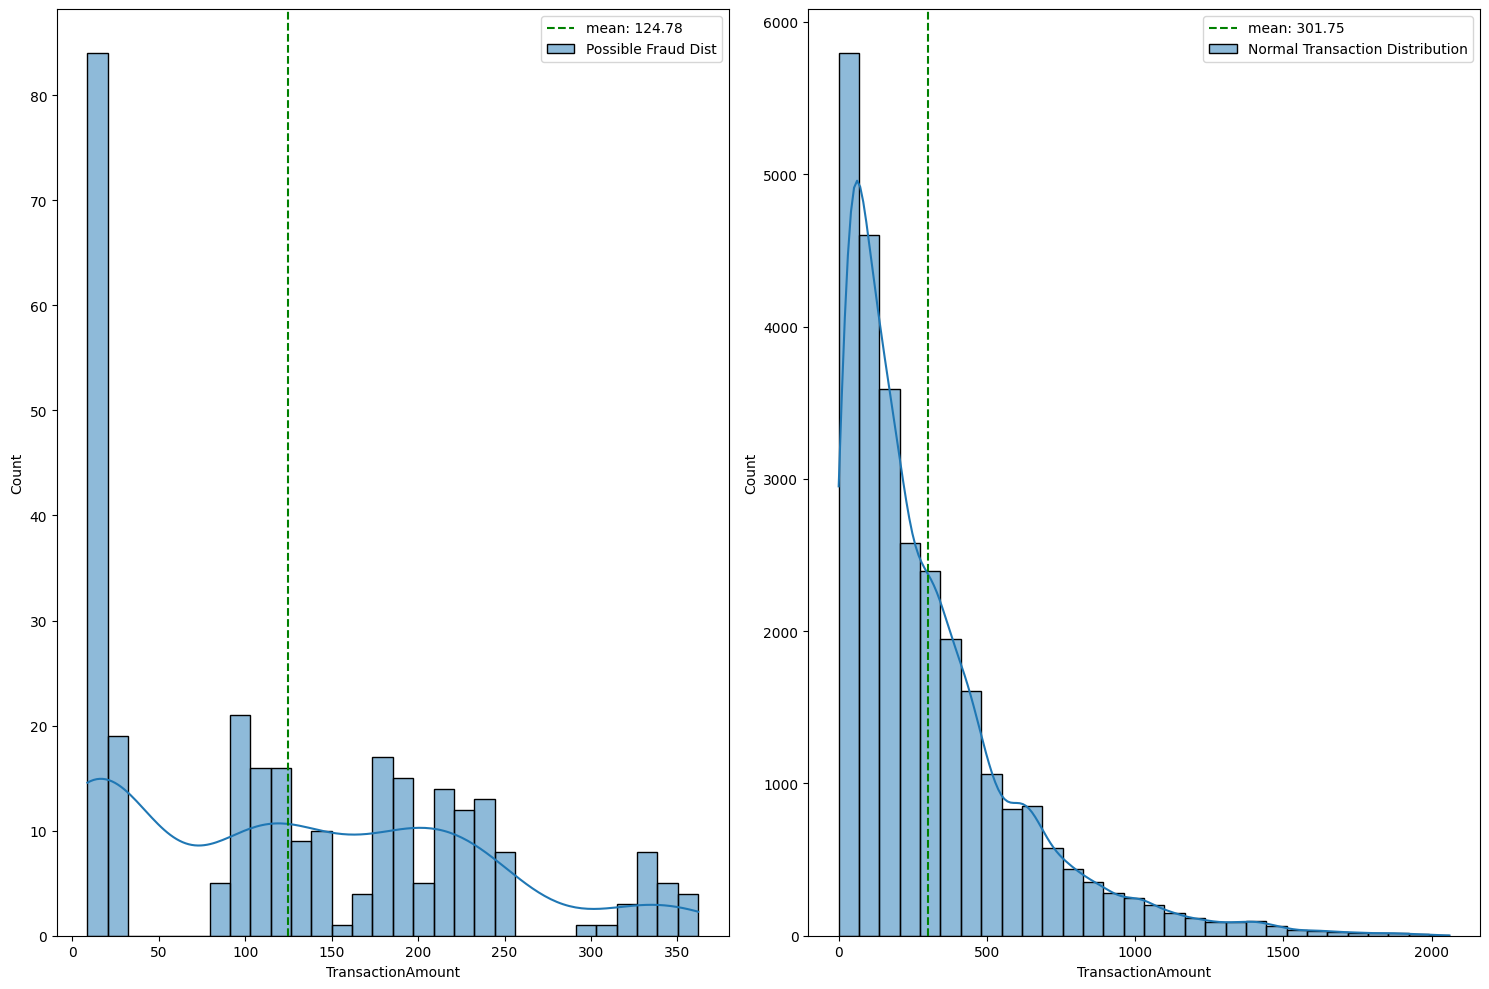

In [25]:
fig, axes= plt.subplots(1,2, figsize=(15, 10))

sns.histplot(sus["TransactionAmount"], bins=30, label="Possible Fraud Dist", ax=axes[0], kde=True)
axes[0].axvline(sus["TransactionAmount"].mean(), linestyle="--", color="green", label=f"mean: {sus['TransactionAmount'].mean():.2f}")
sns.histplot(non_sus["TransactionAmount"], bins=30, label="Normal Transaction Distribution", ax=axes[1], kde=True)
axes[1].axvline(non_sus["TransactionAmount"].mean(), linestyle="--", color="green", label=f"mean: {non_sus['TransactionAmount'].mean():.2f}")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [26]:
len(sus), len(non_sus)

(291, 28109)

In [27]:
sus["Hour"] = sus["TransactionDate"].dt.hour

sus["TimeOfDay"] = np.where(sus["Hour"] < 12, "Morning",
                           np.where(sus["Hour"] < 17, "Afternoon",
                                    np.where(sus["Hour"] < 21, "Evening", "Night"))
                          )

In [28]:
non_sus["Hour"] = non_sus["TransactionDate"].dt.hour

non_sus["TimeOfDay"] = np.where(non_sus["Hour"] < 12, "Morning", 
                                np.where(non_sus["Hour"] < 17, "Afternoon",
                                         np.where(non_sus["Hour"] < 21, "Evening", "Night"))
                               )

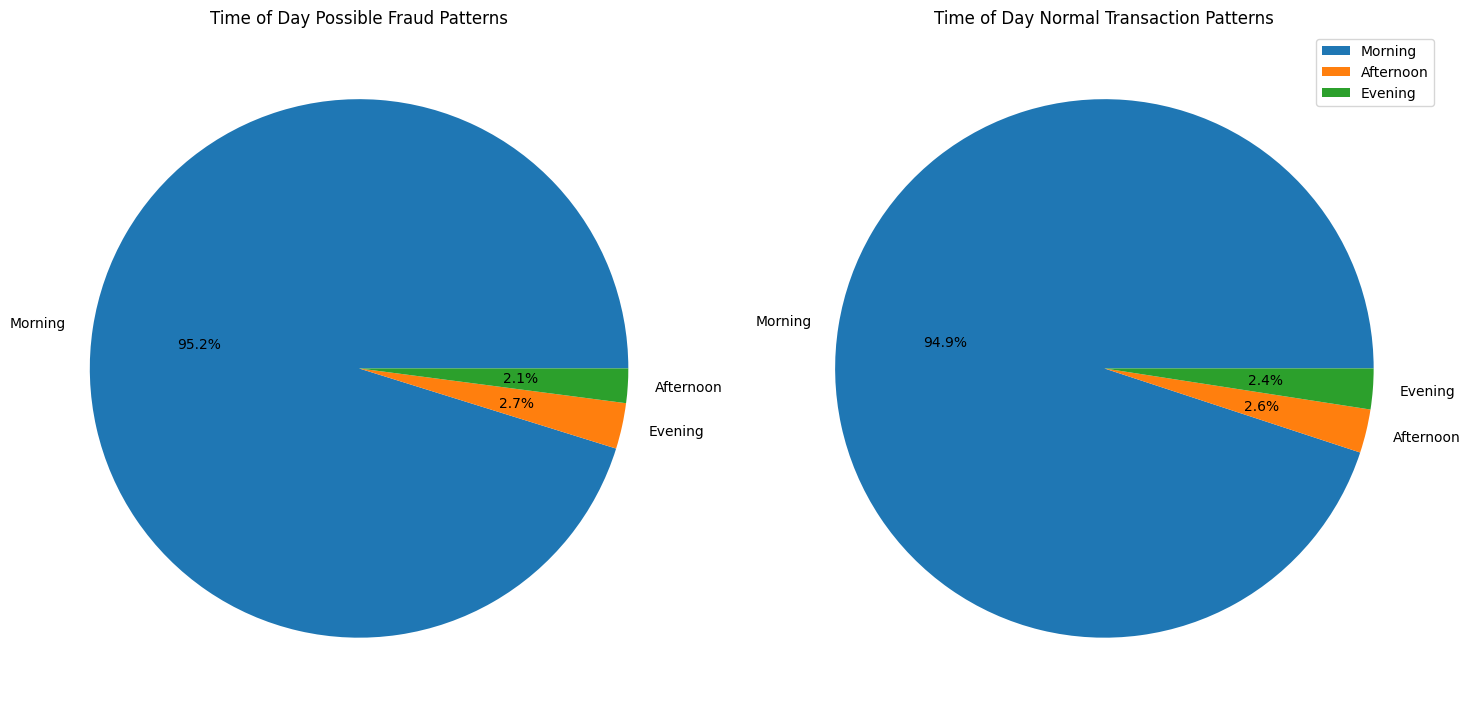

In [29]:
fr_count = sus["TimeOfDay"].value_counts()
nofr_count = non_sus["TimeOfDay"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

fr_count.plot.pie(autopct="%1.1f%%", title="Time of Day Possible Fraud Patterns", ax=axes[0])
nofr_count.plot.pie(autopct="%1.1f%%", title="Time of Day Normal Transaction Patterns", ax=axes[1])
plt.tight_layout()
axes[0].set_ylabel("")
axes[1].set_ylabel("")
plt.legend()
plt.show()

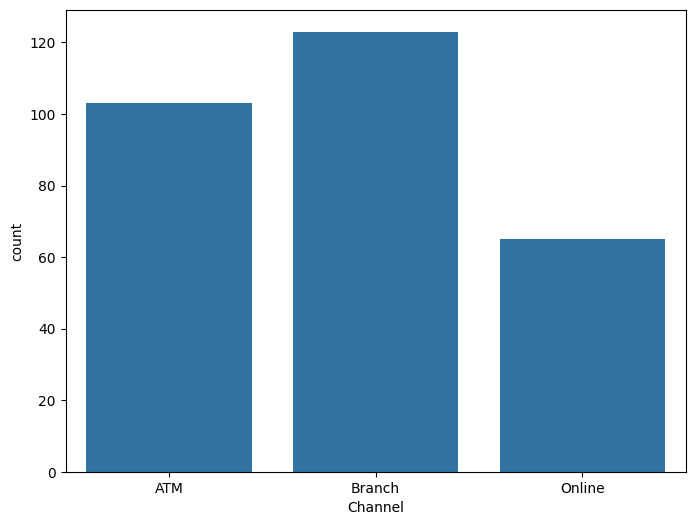

In [30]:
plt.figure(figsize=(8, 6))
sns.countplot(data=sus, x="Channel")
plt.show()

In [31]:
df["TransactionYear"] = pd.to_datetime(df["TransactionDate"]).dt.year
df["TransactionMonth"] = pd.to_datetime(df["TransactionDate"]).dt.month
df["TransactionDay"] = pd.to_datetime(df["TransactionDate"]).dt.dayofweek

# we want just debit transactions
df_debit = df[df["TransactionType"] == "Debit"]

In [32]:
df_debit.drop(["TransactionDate", "TransactionType"], axis=1, inplace=True)

In [33]:
len(df_debit)

38747

In [34]:
count_acc = df_debit.groupby("AccountID")["TransactionAmount"].transform("count")
df_debit["AccountTrans"] = count_acc
count_dev = df_debit.groupby(["AccountID", "DeviceID"])["TransactionAmount"].transform("count")
df_debit["DeviceTrans"] = count_dev
count_merch = df_debit.groupby(["AccountID", "MerchantID"])["TransactionAmount"].transform("count")
df_debit["MerchantID"] = count_merch
count_ip = df_debit.groupby(["AccountID", "IP Address"])["TransactionAmount"].transform("count")
df_debit["IPTrans"] = count_ip

In [35]:
df_debit.head()

,TransactionID,AccountID,TransactionAmount,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionMinute,TransactionYear,TransactionMonth,TransactionDay,AccountTrans,DeviceTrans,IPTrans
0,TX000001,AC00128,14.09,San Diego,D000380,162.198.218.92,23,ATM,70,Doctor,81,1,5112.21,1.350000,2023,4,1,107,23,23
1,TX000002,AC00455,376.24,Houston,D000051,13.149.61.4,15,ATM,68,Doctor,141,1,13758.91,2.350000,2023,6,1,130,15,15
2,TX000003,AC00019,126.29,Mesa,D000235,215.97.143.157,13,Online,19,Student,56,1,1122.35,0.933333,2023,7,0,54,13,13
3,TX000004,AC00070,184.50,Raleigh,D000187,200.13.225.150,19,Online,26,Student,25,1,8569.06,0.416667,2023,5,4,133,19,19
5,TX000006,AC00393,92.15,Oklahoma City,D000579,117.67.192.211,16,ATM,18,Student,172,1,781.68,2.866667,2023,4,0,98,16,16


In [36]:
debit = df_debit.copy()
debit.drop(["TransactionID", "AccountID", "DeviceID", "MerchantID", "IP Address", "TransactionAmount", "AccountBalance"], axis=1, inplace=True)

In [37]:
debit.head(), len(df_debit)

(        Location Channel  CustomerAge CustomerOccupation  TransactionDuration  \
 0      San Diego     ATM           70             Doctor                   81   
 1        Houston     ATM           68             Doctor                  141   
 2           Mesa  Online           19            Student                   56   
 3        Raleigh  Online           26            Student                   25   
 5  Oklahoma City     ATM           18            Student                  172   
 
    LoginAttempts  TransactionMinute  TransactionYear  TransactionMonth  \
 0              1           1.350000             2023                 4   
 1              1           2.350000             2023                 6   
 2              1           0.933333             2023                 7   
 3              1           0.416667             2023                 5   
 5              1           2.866667             2023                 4   
 
    TransactionDay  AccountTrans  DeviceTrans  IPTrans

# Using Anomaly Machine Learning Algorithm (Isolation Forest)

In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest

In [39]:
cat_col = []

for col in debit.columns:
    if debit[col].dtype == "str":
        cat_col.append(col)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), cat_col)
    ])

X = preprocessor.fit_transform(debit)
cat_col = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_col)
col_names = list(cat_col)
X = pd.DataFrame(X.toarray(), columns=col_names)
X.head()

,Location_Albuquerque,Location_Atlanta,Location_Austin,Location_Baltimore,Location_Boston,Location_Charlotte,Location_Chicago,Location_Colorado Springs,Location_Columbus,Location_Dallas,...,Location_Tucson,Location_Virginia Beach,Location_Washington,Channel_ATM,Channel_Branch,Channel_Online,CustomerOccupation_Doctor,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [41]:
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [42]:
pred = model.predict(X)
len(pred)

38747

In [43]:
len(X)

38747

In [44]:
df_debit["Anomaly"] = pred

In [45]:
df_debit.reset_index(drop=True).head(1)

,TransactionID,AccountID,TransactionAmount,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,...,LoginAttempts,AccountBalance,TransactionMinute,TransactionYear,TransactionMonth,TransactionDay,AccountTrans,DeviceTrans,IPTrans,Anomaly
0,TX000001,AC00128,14.09,San Diego,D000380,162.198.218.92,23,ATM,70,Doctor,...,1,5112.21,1.35,2023,4,1,107,23,23,1


# Investigating the Segmented Datapoints

In [46]:
df_debit.groupby("Anomaly").agg({
    "TransactionAmount": "median",
    "Location": lambda x: x.mode()[0],
    "Channel": lambda x: x.mode()[0],
    "CustomerAge": "median",
    "CustomerOccupation": lambda x: x.mode()[0],
    "TransactionDuration": "median",
    "LoginAttempts": "median",
    "AccountBalance": "median",
    "TransactionMinute": "median",
    "TransactionYear": lambda x: x.mode()[0],
    "TransactionDay": lambda x: x.mode()[0],
    "AccountTrans": "median",
    "DeviceTrans": "median",
    "IPTrans": "median",
})

,TransactionAmount,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionMinute,TransactionYear,TransactionDay,AccountTrans,DeviceTrans,IPTrans
Anomaly,,,,,,,,,,,,,,
-1,190.25,Indianapolis,ATM,37.0,Student,123.0,1.0,5424.60,2.050000,2023,0,90.0,20.0,20.0
1,206.87,Charlotte,ATM,45.0,Student,110.0,1.0,4671.69,1.833333,2023,0,94.0,21.0,21.0


In [47]:
suspiscious = df_debit[df_debit["Anomaly"] == -1]
normal = df_debit[df_debit["Anomaly"] == 1]

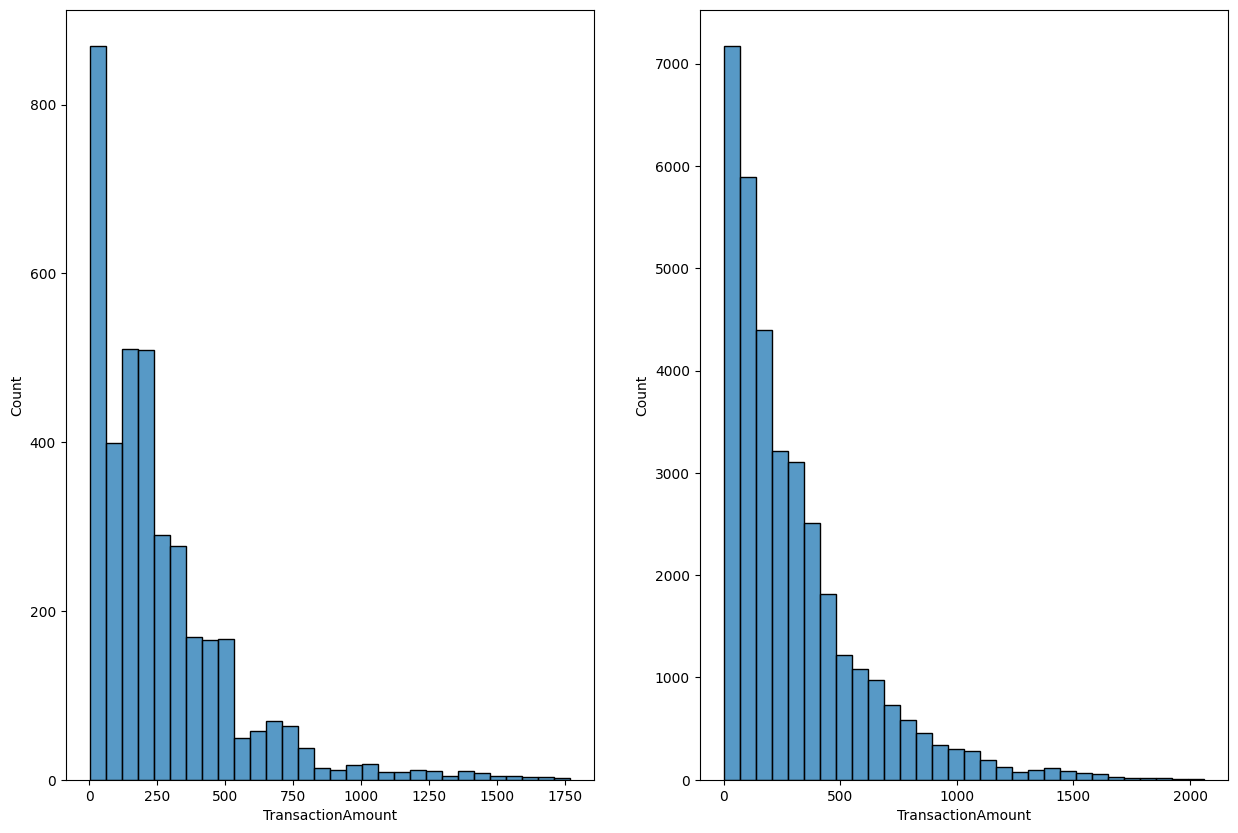

In [48]:
fig, axes = plt.subplots(1,2, figsize=(15, 10))

sns.histplot(data=suspiscious, x="TransactionAmount", bins=30, ax=axes[0])
sns.histplot(data=normal, x="TransactionAmount", bins=30, ax=axes[1])
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11680\661002495.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\USER\AppData\Local\Temp\ipykernel_11680\661002495.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


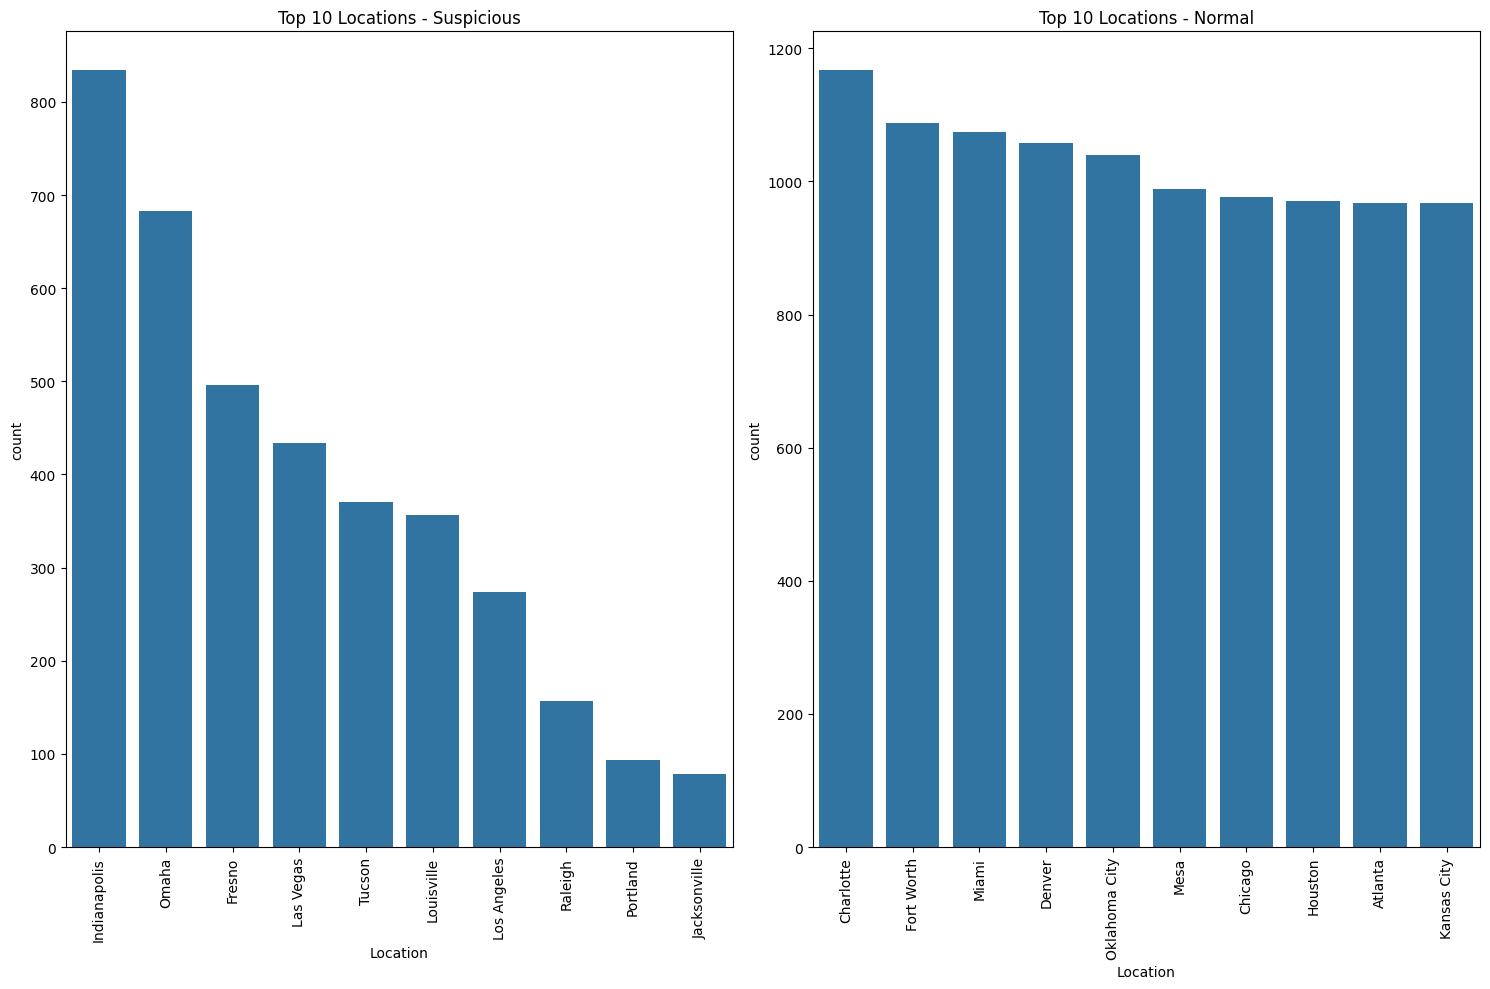

In [49]:
# Get top 10 locations
sus_loc = suspiscious['Location'].value_counts().reset_index().head(10)
sus_loc.columns = ['Location', 'count']

nor_loc = normal['Location'].value_counts().reset_index().head(10)
nor_loc.columns = ['Location', 'count']

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.barplot(data=sus_loc, x="Location", y="count", ax=axes[0])
sns.barplot(data=nor_loc, x="Location", y="count", ax=axes[1])

# Rotate x-axis labels
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

axes[0].set_title("Top 10 Locations - Suspicious")
axes[1].set_title("Top 10 Locations - Normal")

plt.tight_layout()
plt.show()

In [50]:
len(df_debit["Location"].unique())

43

C:\Users\USER\AppData\Local\Temp\ipykernel_11680\1896957463.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\USER\AppData\Local\Temp\ipykernel_11680\1896957463.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


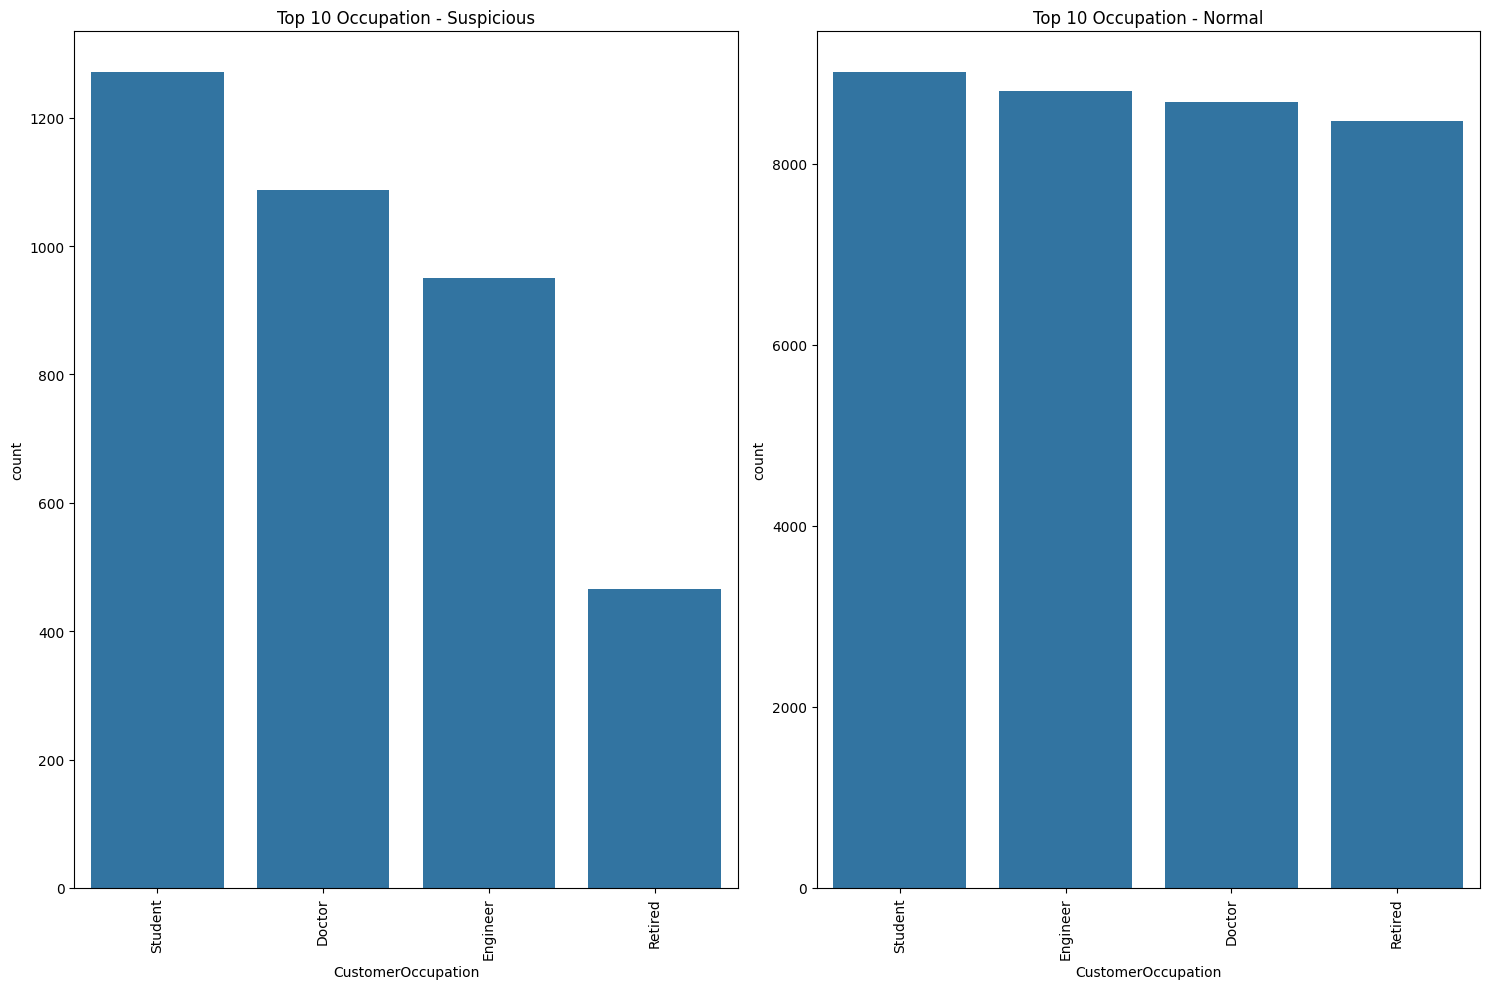

In [51]:
# Get top 10 locations
sus_occ=suspiscious['CustomerOccupation'].value_counts().reset_index().head(10)
sus_occ.columns = ['CustomerOccupation', 'count']

nor_occ = normal['CustomerOccupation'].value_counts().reset_index().head(10)
nor_occ.columns = ['CustomerOccupation', 'count']

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.barplot(data=sus_occ, x="CustomerOccupation", y="count", ax=axes[0])
sns.barplot(data=nor_occ, x="CustomerOccupation", y="count", ax=axes[1])

# Rotate x-axis labels
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

axes[0].set_title("Top 10 Occupation - Suspicious")
axes[1].set_title("Top 10 Occupation - Normal")

plt.tight_layout()
plt.show()

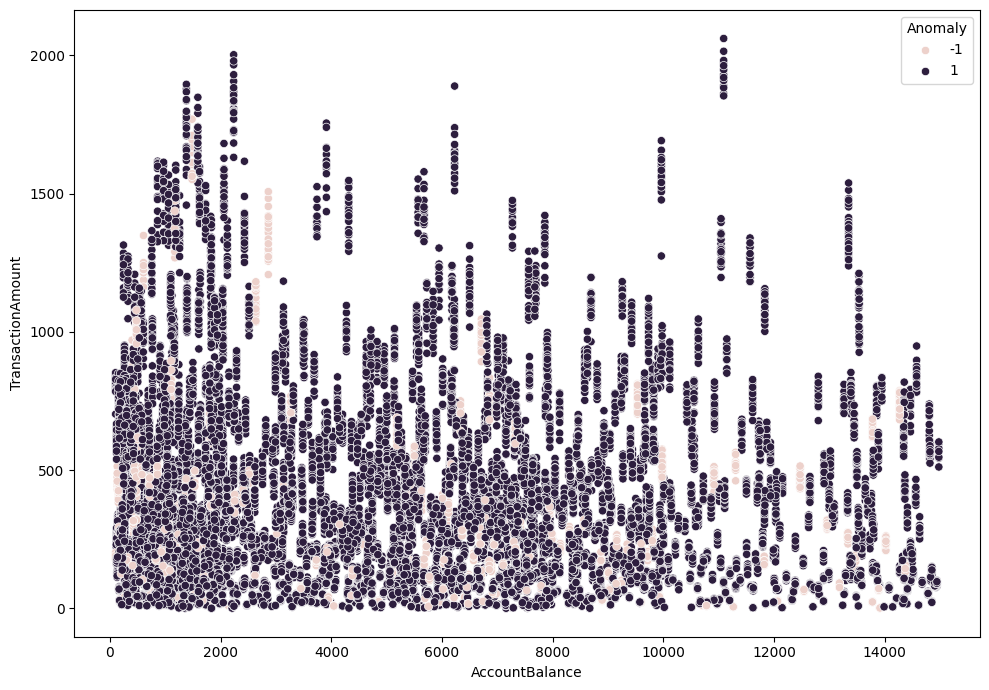

In [52]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_debit,
    x="AccountBalance",
    y="TransactionAmount",
    hue="Anomaly"
)
plt.tight_layout()
plt.show()

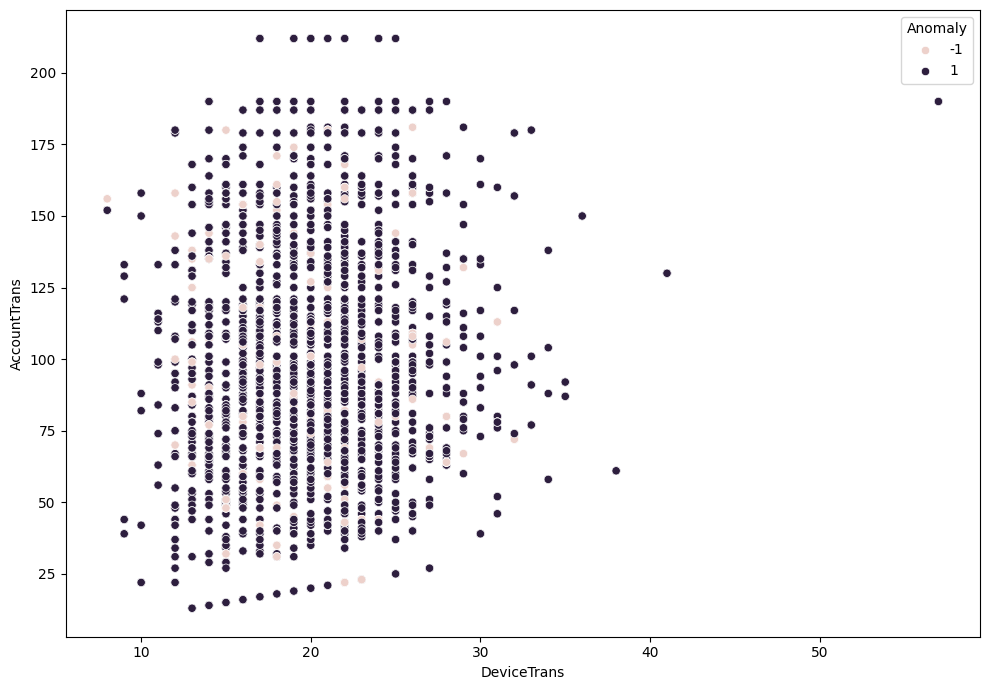

In [53]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_debit,
    x="DeviceTrans",
    y="AccountTrans",
    hue="Anomaly"
)
plt.tight_layout()
plt.show()

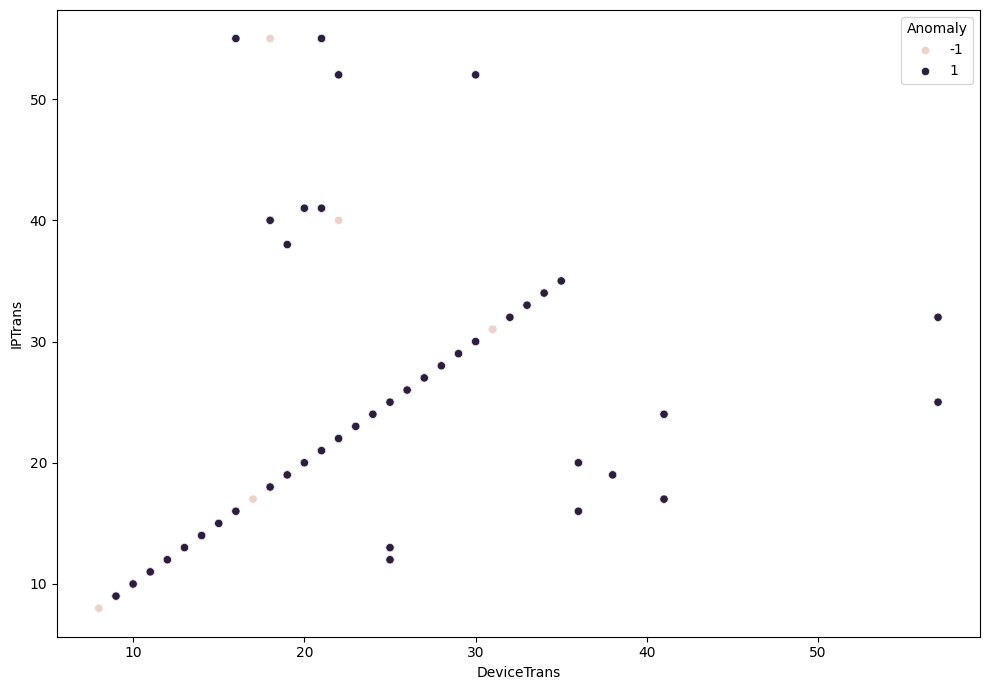

In [54]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_debit,
    x="DeviceTrans",
    y="IPTrans",
    hue="Anomaly"
)
plt.tight_layout()
plt.show()

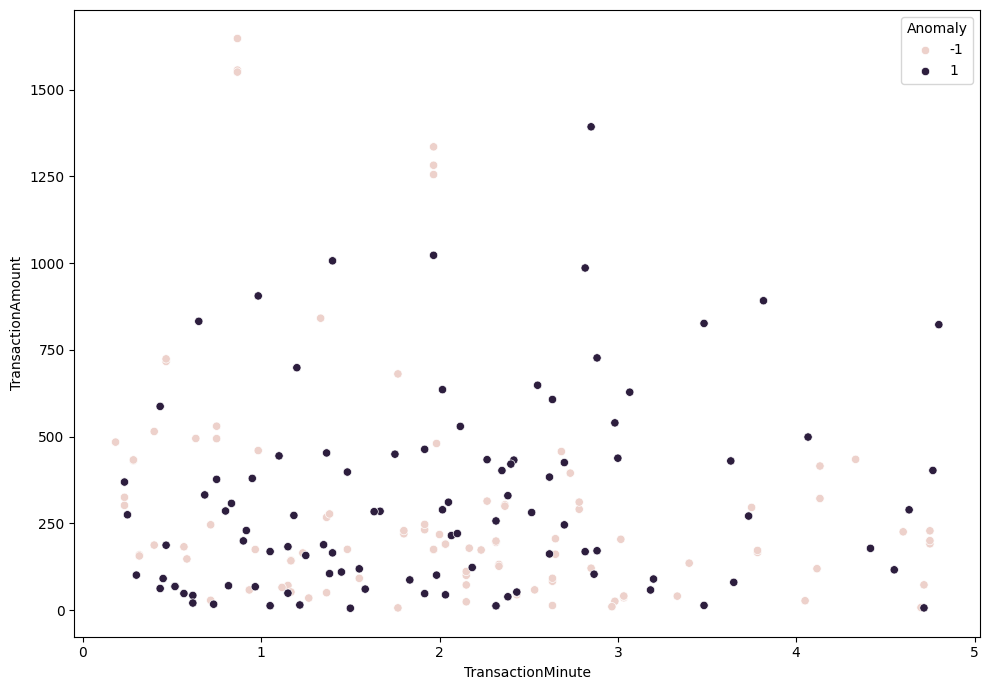

In [55]:
sample_df = df_debit.groupby("Anomaly").sample(100, random_state=42)
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=sample_df,
    x="TransactionMinute",
    y="TransactionAmount",
    hue="Anomaly"
)
plt.tight_layout()
plt.show()

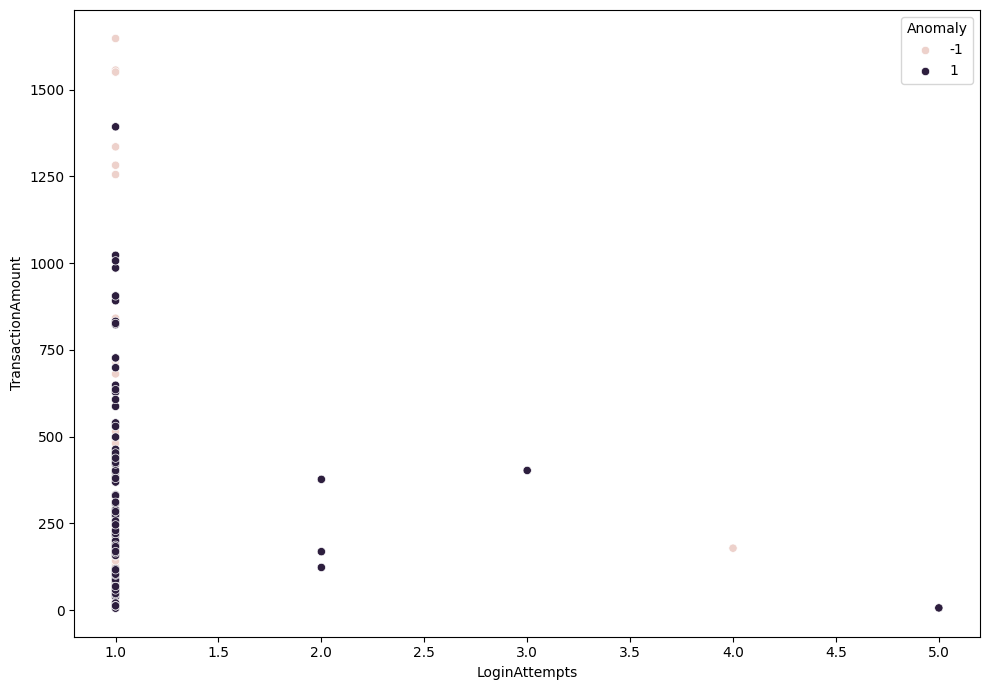

In [56]:
sample_df = df_debit.groupby("Anomaly").sample(100, random_state=42)
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=sample_df,
    x="LoginAttempts",
    y="TransactionAmount",
    hue="Anomaly"
)
plt.tight_layout()
plt.show()

In [57]:
df_debit["anomaly_score"] = model.decision_function(X)

In [58]:
df_debit.head()

,TransactionID,AccountID,TransactionAmount,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,...,AccountBalance,TransactionMinute,TransactionYear,TransactionMonth,TransactionDay,AccountTrans,DeviceTrans,IPTrans,Anomaly,anomaly_score
0,TX000001,AC00128,14.09,San Diego,D000380,162.198.218.92,23,ATM,70,Doctor,...,5112.21,1.350000,2023,4,1,107,23,23,1,0.017119
1,TX000002,AC00455,376.24,Houston,D000051,13.149.61.4,15,ATM,68,Doctor,...,13758.91,2.350000,2023,6,1,130,15,15,1,0.013315
2,TX000003,AC00019,126.29,Mesa,D000235,215.97.143.157,13,Online,19,Student,...,1122.35,0.933333,2023,7,0,54,13,13,1,0.008694
3,TX000004,AC00070,184.50,Raleigh,D000187,200.13.225.150,19,Online,26,Student,...,8569.06,0.416667,2023,5,4,133,19,19,1,0.011704
5,TX000006,AC00393,92.15,Oklahoma City,D000579,117.67.192.211,16,ATM,18,Student,...,781.68,2.866667,2023,4,0,98,16,16,1,0.022436


C:\Users\USER\AppData\Local\Temp\ipykernel_11680\2005471368.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


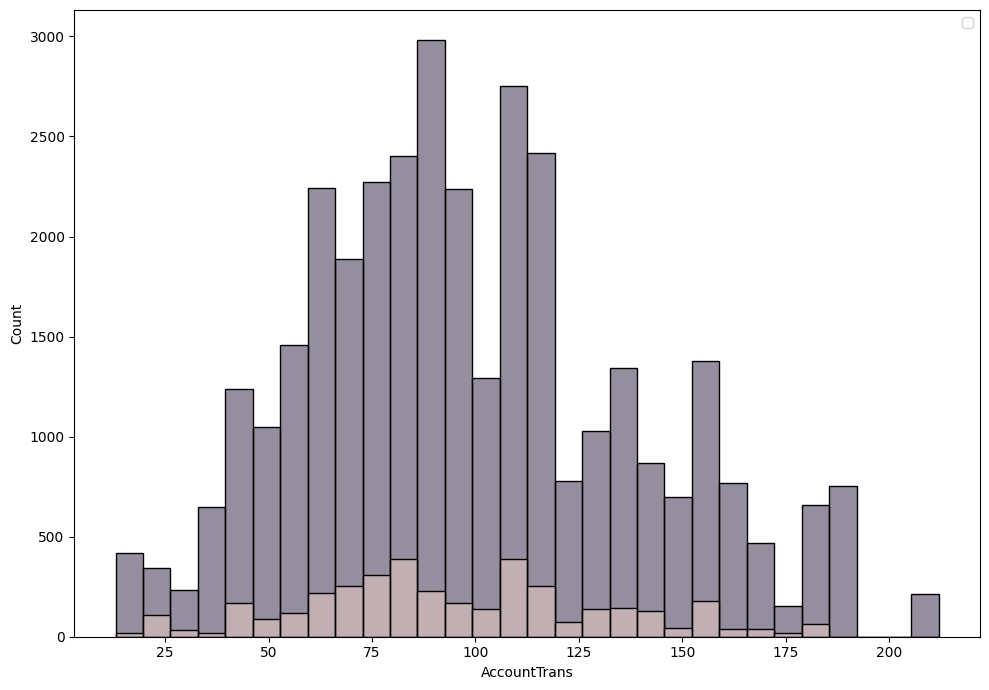

In [59]:
plt.figure(figsize=(10, 7))
sns.histplot(data=df_debit, x="AccountTrans", bins=30, hue="Anomaly")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11680\720429571.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\USER\AppData\Local\Temp\ipykernel_11680\720429571.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


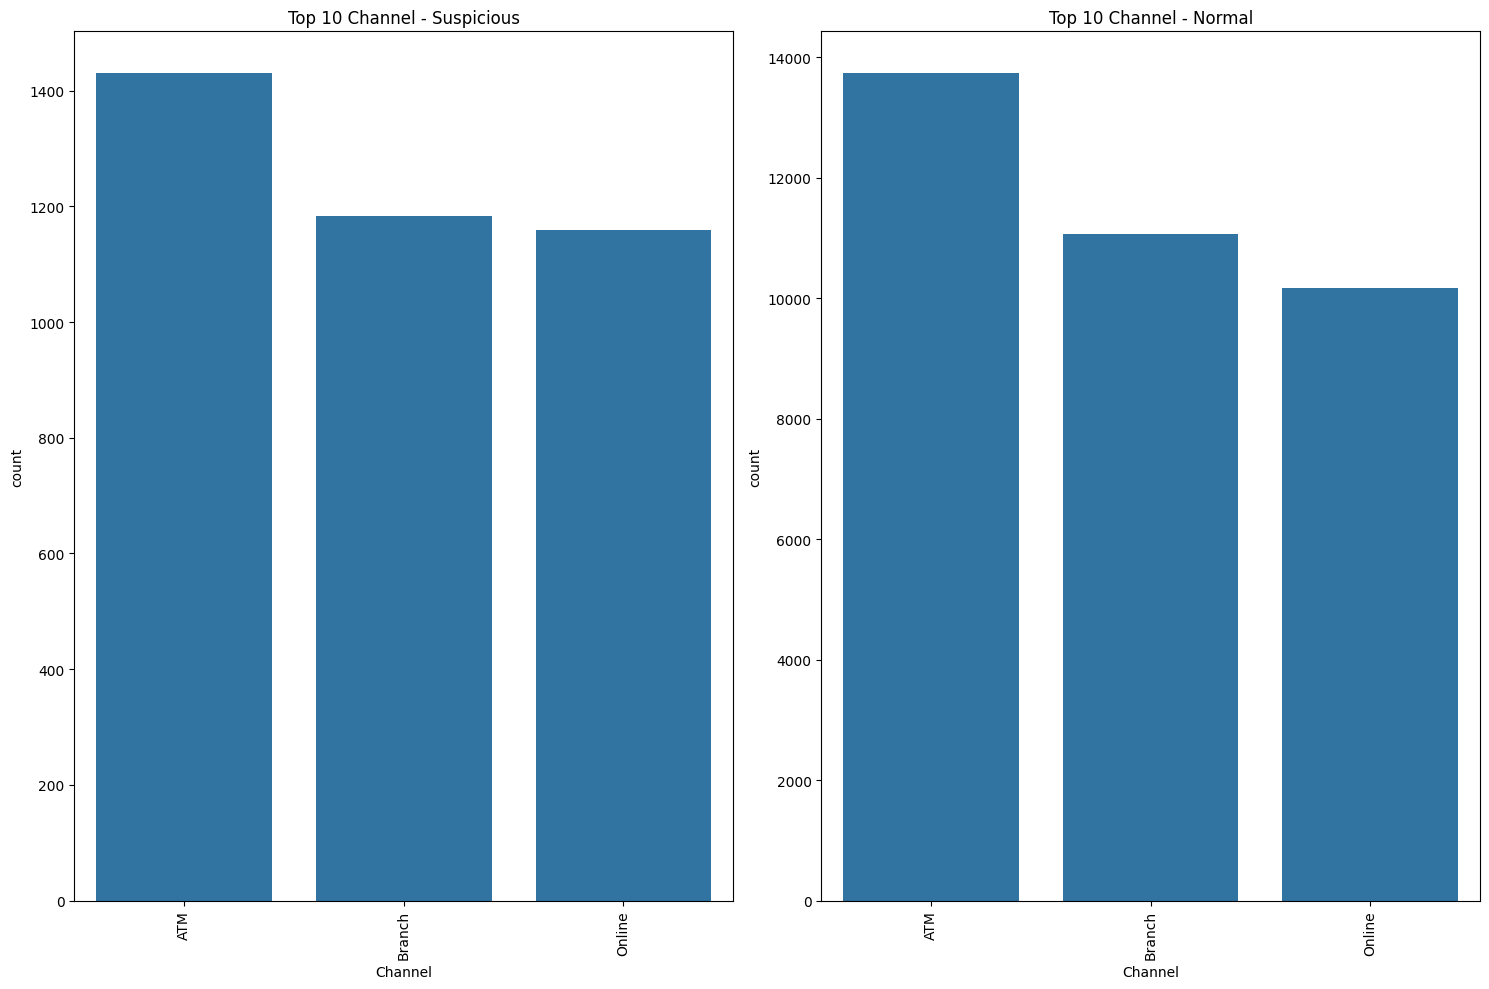

In [60]:
# Get top 10 locations
sus_cha=suspiscious['Channel'].value_counts().reset_index().head(10)
sus_cha.columns = ['Channel', 'count']

nor_cha = normal['Channel'].value_counts().reset_index().head(10)
nor_cha.columns = ['Channel', 'count']

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.barplot(data=sus_cha, x="Channel", y="count", ax=axes[0])
sns.barplot(data=nor_cha, x="Channel", y="count", ax=axes[1])

# Rotate x-axis labels
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

axes[0].set_title("Top 10 Channel - Suspicious")
axes[1].set_title("Top 10 Channel - Normal")

plt.tight_layout()
plt.show()